In [9]:
import pandas as pd 
from sklearn.model_selection import train_test_split

df= pd.read_csv("cleaned-2.csv")
df

,Unnamed: 0,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,LTV,Status,dtir1,loan_to_income,loan_to_collateral,interest_burden,total_cost_proxy,risk_score
0,0,cf,Sex Not Available,nopre,type1,p1,l1,nob/c,116500,3.990,...,EXP,758,98.728814,1,45.0,66.916,0.987,464835.0,467526.13,-16.8
1,1,cf,Male,nopre,type2,p1,l1,b/c,206500,3.990,...,EQUI,552,75.297619,1,40.0,41.458,0.494,823935.0,826626.13,104.8
2,2,cf,Male,pre,type1,p1,l1,nob/c,406500,4.560,...,EXP,834,80.019685,0,46.0,42.875,0.800,1853640.0,1854235.00,-62.0
3,3,cf,Male,nopre,type1,p4,l1,nob/c,456500,4.250,...,EXP,587,69.376900,0,42.0,38.423,0.694,1940125.0,1942816.13,84.6
4,4,cf,Joint,pre,type1,p1,l1,nob/c,696500,4.000,...,CRIF,602,91.886544,0,39.0,66.708,0.919,2786000.0,2786000.00,74.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1504,1504,cf,Joint,pre,type3,p1,l1,nob/c,236500,4.375,...,CIB,533,99.369748,0,44.0,40.214,0.994,1034687.5,1036987.50,117.8
1505,1505,cf,Sex Not Available,nopre,type3,p3,l1,nob/c,196500,3.990,...,EQUI,834,75.297619,1,40.0,72.751,0.470,784035.0,786726.13,-64.4
1506,1506,cf,Male,nopre,type2,p4,l1,b/c,116500,3.990,...,EXP,624,73.734177,1,26.0,49.765,0.737,464835.0,467526.13,56.0
1507,1507,cf,Male,nopre,type1,p3,l1,nob/c,136500,3.990,...,EXP,840,72.606383,0,38.0,45.485,0.726,544635.0,547745.38,-68.8


In [11]:
# remove useless index column
df = df.drop("Unnamed: 0", axis=1)

# convert all object/string columns
df = pd.get_dummies(df, drop_first=True)

In [12]:
X= df.drop("Status", axis=1 )
y=df["Status"]
X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state= 42, stratify=y )

In [16]:
from sklearn.preprocessing import StandardScaler
print(X_train.dtypes[X_train.dtypes == 'object'])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Series([], dtype: object)


In [17]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
y_pred_lin = svm_linear.predict(X_test_scaled)

svm_linear = SVC(kernel='linear',C=1,class_weight='balanced')
svm_linear.fit(X_train_scaled, y_train)
print("=== SVM Linear ===")
print("Classification report :\n", classification_report(y_test, y_pred_lin))
print("confusion matrix: \n", confusion_matrix(y_test,y_pred_lin))

=== SVM Linear ===
Classification report :
               precision    recall  f1-score   support

           0       0.87      0.88      0.87       227
           1       0.62      0.60      0.61        75

    accuracy                           0.81       302
   macro avg       0.74      0.74      0.74       302
weighted avg       0.81      0.81      0.81       302

confusion matrix: 
 [[199  28]
 [ 30  45]]


In [21]:
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    class_weight='balanced'
)

svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix

print("classification report:\n",classification_report(y_test, y_pred_rbf))
print("\n confusion matrix : \n" ,confusion_matrix(y_test, y_pred_rbf))

classification report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88       227
           1       0.64      0.68      0.66        75

    accuracy                           0.82       302
   macro avg       0.76      0.78      0.77       302
weighted avg       0.83      0.82      0.83       302


 confusion matrix : 
 [[198  29]
 [ 24  51]]


In [23]:
svm_rbf5 = SVC(
    kernel='rbf',
    C=5,
    class_weight='balanced'
)

svm_rbf5.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf5.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_rbf))
print(confusion_matrix(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90       227
           1       0.68      0.69      0.69        75

    accuracy                           0.84       302
   macro avg       0.79      0.79      0.79       302
weighted avg       0.85      0.84      0.84       302

[[203  24]
 [ 23  52]]


In [26]:
svm_rbf10 = SVC(
    kernel='rbf',
    C=10,
    class_weight='balanced'
)

svm_rbf10.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf10.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_rbf))
print(confusion_matrix(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       227
           1       0.70      0.69      0.70        75

    accuracy                           0.85       302
   macro avg       0.80      0.80      0.80       302
weighted avg       0.85      0.85      0.85       302

[[205  22]
 [ 23  52]]


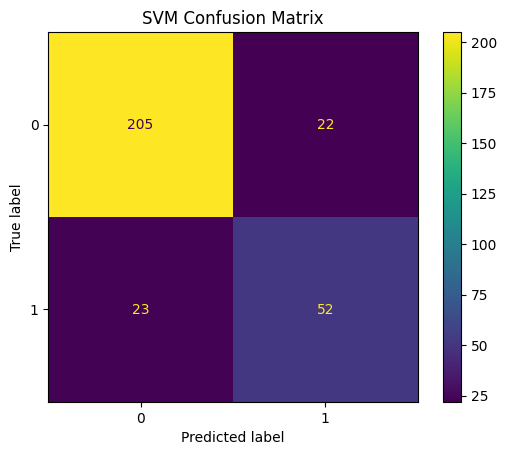

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rbf)
plt.title("SVM Confusion Matrix")
plt.show()

In [24]:
# best result turns out to be when the c=10 as the FN false negatives are the least recallls for [1] defaulters are highest and f1 score is also good.
import pickle 
with open("svm.pkl","wb") as f :
    pickle.dump(svm_rbf10,f)
print("model loaded")

model loaded
